# [TEMP] 1. Anatomy of an Inference Request

Every LLM request goes through two very different phases:

**Prefill**
: The model reads the whole prompt in one forward pass and writes the
  key/value (KV) vectors of every prompt token into the **KV cache**. It
  ends by emitting the first output token.

**Decode**
: The model generates the remaining tokens one at a time. Each step does a
  forward pass for a *single* new token per request, reusing the KV cache.

Users experience these two phases as two separate latencies:

| Metric | Definition | Dominated by |
|---|---|---|
| **TTFT** (time to first token) | arrival → first token | queueing + prefill |
| **TPOT** (time per output token) | average gap between later tokens | decode steps |
| **E2E latency** | arrival → last token | ≈ TTFT + TPOT × (output tokens − 1) |

In this lab you will measure all three in simulation and work out *why* prefill
and decode scale so differently.

:::{admonition} Learning goals
- Measure TTFT, TPOT and E2E latency for a single model on a single GPU.
- Explain why prefill time grows with prompt length but decode time per token barely does.
- Estimate decode latency from first principles (weights ÷ memory bandwidth).
:::

## Setup

This cell works unchanged on Colab, Binder and a local install. The first run
clones the simulator and installs its
dependencies, which takes about a minute.

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # running outside the course repo (e.g. Colab): fetch the helper
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

Simulator ready at /home/kiwan/.llm-systems-wo-gpus/backend


## A single request, alone on the GPU

We simulate **Llama-2-7B on one A100**. The workload is one request at a time:
`qps=0.05` means a new request arrives every 20 s on average, so they never
overlap and there is no queueing.

The first call for a given (model, GPU, parallelism) takes ~15 s because the simulator
fits its runtime predictors from profiling data. Later calls reuse the cache
and finish in a few seconds.

In [2]:
r = lsg.simulate(qps=0.05, num_requests=20, prefill_tokens=512, decode_tokens=128)
r.summary()

requests               20.000
TTFT p50 (ms)          36.554
TTFT p99 (ms)          36.554
TPOT p50 (ms)           9.449
TPOT p99 (ms)           9.449
E2E p50 (s)             1.246
queueing p50 (ms)       0.000
throughput (tok/s)     28.568
makespan (s)          448.048
dtype: float64

`r.requests` holds one row per request with every metric the simulator records:

In [3]:
r.requests[["request_num_prefill_tokens", "request_num_decode_tokens",
            "prefill_e2e_time", "decode_time_execution_plus_preemption_normalized",
            "request_e2e_time"]].head()

,request_num_prefill_tokens,request_num_decode_tokens,prefill_e2e_time,decode_time_execution_plus_preemption_normalized,request_e2e_time
0,512,128,0.036554,0.009449,1.246058
1,512,128,0.036554,0.009449,1.246058
2,512,128,0.036554,0.009449,1.246058
3,512,128,0.036554,0.009449,1.246058
4,512,128,0.036554,0.009449,1.246058


Check the E2E formula from the table above: TTFT + TPOT × 127 should come
close to the measured E2E latency.

In [4]:
s = r.summary()
print(f"TTFT + 127*TPOT = {s['TTFT p50 (ms)'] + 127 * s['TPOT p50 (ms)']:.0f} ms;"
      f"  measured E2E = {1e3 * s['E2E p50 (s)']:.0f} ms")

TTFT + 127*TPOT = 1237 ms;  measured E2E = 1246 ms


## Prefill scales with the prompt

Now vary the prompt length and keep the output fixed at 32 tokens.

:::{note}
Llama-2-7B has a 4,096-token context window, and that is also as far as it was
profiled. The simulator predicts kernel runtimes by **interpolating** profiled
measurements, so it cannot tell you what happens past that range. If you ask it
to, it silently returns the value at the edge. `lsg.catalog()` lists the profiled
limits of every model and GPU.
:::

In [5]:
prompt = lsg.sweep("prefill_tokens", [128, 256, 512, 1024, 1536, 2048, 3072, 4000],
                  decode_tokens=32, qps=0.05, num_requests=10)
prompt[["TTFT p50 (ms)", "TPOT p50 (ms)"]]

,TTFT p50 (ms),TPOT p50 (ms)
prefill_tokens,,
128.0,13.188,9.137
256.0,19.567,9.173
512.0,36.554,9.204
1024.0,74.353,9.387
1536.0,113.202,9.537
2048.0,153.388,9.722
3072.0,237.015,10.168
4000.0,321.583,10.438


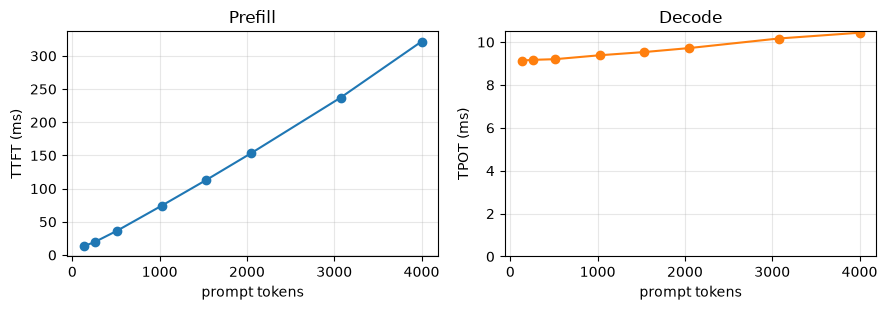

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(prompt.index, prompt["TTFT p50 (ms)"], "o-")
ax[0].set(xlabel="prompt tokens", ylabel="TTFT (ms)", title="Prefill")
ax[1].plot(prompt.index, prompt["TPOT p50 (ms)"], "o-", color="C1")
ax[1].set(xlabel="prompt tokens", ylabel="TPOT (ms)", title="Decode", ylim=(0, None))
fig.tight_layout()

TTFT grows roughly **linearly** with the prompt, and a little faster than
linear for long prompts, because attention cost grows with the square of the
sequence length. TPOT barely moves, even though every decode step has to read
the whole prompt's KV cache.

## Why decode is (almost) flat: memory-bound vs. compute-bound

Compare the work done per byte of weights read:

- **Prefill** multiplies an $N \times d$ activation matrix by each weight
  matrix. Each weight byte is loaded once and reused $N$ times, so for large
  $N$ the GPU is **compute-bound**.
- **Decode** (batch of one) multiplies a single $1 \times d$ vector by each
  weight matrix. Each weight byte is loaded once and used *once*, so the GPU is
  **memory-bandwidth-bound**.

That gives a back-of-the-envelope lower bound on decode time:

$$
\text{TPOT} \gtrsim \frac{\text{weight bytes}}{\text{HBM bandwidth}}
= \frac{7\times 10^9 \times 2\ \text{B}}{2.0\ \text{TB/s}} \approx 7\ \text{ms}.
$$

In [7]:
weights_bytes = 6.7e9 * 2          # Llama-2-7B, fp16
a100_bw = 2.0e12                   # A100-80GB HBM2e, bytes/s
print(f"Roofline TPOT bound: {1e3 * weights_bytes / a100_bw:.1f} ms;"
      f"  simulated TPOT: {r.summary()['TPOT p50 (ms)']:.1f} ms")

Roofline TPOT bound: 6.7 ms;  simulated TPOT: 9.4 ms


The simulated TPOT is within a factor of ~1.5 of the bound. The gap comes from
kernel launch overheads, attention over the KV cache, and the fact that real
kernels do not reach peak bandwidth. The simulator's numbers come from **profiled** kernel
runtimes on real A100s, so they include these effects.

## Decode scales with the output

With the prompt fixed, E2E latency is a straight line in the number of output
tokens, and its slope is the TPOT.

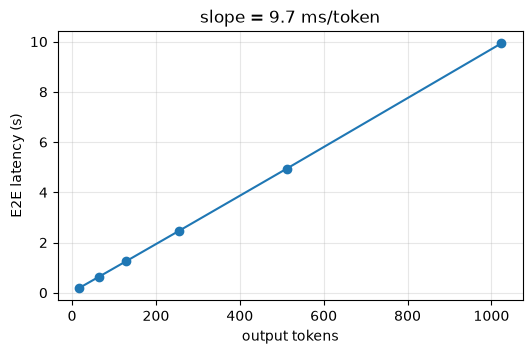

In [8]:
out = lsg.sweep("decode_tokens", [16, 64, 128, 256, 512, 1024],
               prefill_tokens=512, qps=0.05, num_requests=10)
plt.plot(out.index, out["E2E p50 (s)"], "o-")
plt.xlabel("output tokens"); plt.ylabel("E2E latency (s)")
slope = (out["E2E p50 (s)"].iloc[-1] - out["E2E p50 (s)"].iloc[0]) / (out.index[-1] - out.index[0])
plt.title(f"slope = {1e3 * slope:.1f} ms/token");

For a typical chat request (a few hundred prompt tokens, a few hundred output
tokens), **decode dominates E2E latency**. For summarization or retrieval-augmented
prompts with thousands of input tokens, prefill can dominate instead.

## Exercises

:::{admonition} Try it
:class: exercise
1. Repeat the prompt-length sweep for `model="meta-llama/Meta-Llama-3-8B"`.
   Llama-3 has a larger vocabulary and uses grouped-query attention (GQA).
   Which of TTFT and TPOT changes more, and why?
2. Switch to an H100 (`device="h100"`).
   H100 has ~1.7× the memory bandwidth and ~3× the dense FP16 FLOPs of an A100.
   Predict the TTFT and TPOT speedups *before* you run it, then check.
3. Using the roofline argument, estimate TPOT for a 70B model on one GPU.
   Why can't you actually run that configuration? (Hint: 70B × 2 bytes.)
:::